In [36]:
import pandas as pd
import numpy as np

In [37]:
ratings = pd.read_csv("ratings_small.csv")

In [38]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [39]:
!pip install scikit-surprise

In [40]:
!pip install "numpy<2"

In [41]:
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

In [42]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [43]:
from surprise import KNNBasic

sim_options = {
    "name": "msd",
    "user_based": True,
}

user_based_cf = KNNBasic(sim_options=sim_options)

In [44]:
results_user_cf = cross_validate(user_based_cf, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9688  0.9659  0.9677  0.9666  0.9667  0.9671  0.0010  
MAE (testset)     0.7442  0.7433  0.7457  0.7439  0.7418  0.7438  0.0013  
Fit time          0.10    0.11    0.13    0.12    0.11    0.11    0.01    
Test time         1.00    1.34    1.23    0.98    0.94    1.10    0.16    


In [45]:
avg_rmse_user = results_user_cf['test_rmse'].mean()
avg_mae_user = results_user_cf['test_mae'].mean()

In [46]:
sim_options_item = {
    'name': 'msd',
    'user_based': False
}

In [47]:
item_based_cf = KNNBasic(sim_options=sim_options_item)

In [48]:
results_item_cf = cross_validate(item_based_cf, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9388  0.9365  0.9385  0.9310  0.9326  0.9355  0.0032  
MAE (testset)     0.7240  0.7232  0.7217  0.7160  0.7218  0.7213  0.0028  
Fit time          3.61    3.50    3.57    3.54    3.49    3.54    0.05    
Test time         4.34    4.53    4.37    4.55    4.36    4.43    0.09    


In [49]:
avg_rmse_item = results_item_cf['test_rmse'].mean()
avg_mae_item = results_item_cf['test_mae'].mean()

In [50]:
from surprise import SVD

In [51]:
pmf = SVD()

In [52]:
results_pmf = cross_validate(pmf, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8937  0.9007  0.8937  0.8845  0.9011  0.8947  0.0060  
MAE (testset)     0.6889  0.6909  0.6889  0.6828  0.6928  0.6888  0.0034  
Fit time          0.95    0.92    0.95    0.88    0.92    0.92    0.03    
Test time         0.21    0.08    0.20    0.08    0.20    0.16    0.06    


In [53]:
avg_rmse_pmf = results_pmf['test_rmse'].mean()
avg_mae_pmf = results_pmf['test_mae'].mean()

In [54]:
print("\nRMSE Comparison:")
print(f"User-based CF:  {avg_rmse_user:.4f}")
print(f"Item-based CF:  {avg_rmse_item:.4f}")
print(f"PMF (SVD):      {avg_rmse_pmf:.4f}")

print("\nMAE Comparison:")
print(f"User-based CF:  {avg_mae_user:.4f}")
print(f"Item-based CF:  {avg_mae_item:.4f}")
print(f"PMF (SVD):      {avg_mae_pmf:.4f}")


RMSE Comparison:
User-based CF:  0.9671
Item-based CF:  0.9355
PMF (SVD):      0.8947

MAE Comparison:
User-based CF:  0.7438
Item-based CF:  0.7213
PMF (SVD):      0.6888


In [55]:
best_rmse_model = min([('User-based CF', avg_rmse_user),
                       ('Item-based CF', avg_rmse_item),
                       ('PMF', avg_rmse_pmf)], key=lambda x: x[1])

best_mae_model = min([('User-based CF', avg_mae_user),
                      ('Item-based CF', avg_mae_item),
                      ('PMF', avg_mae_pmf)], key=lambda x: x[1])

In [56]:
print(f"Best model by RMSE: {best_rmse_model[0]} ({best_rmse_model[1]:.4f})")
print(f"Best model by MAE:  {best_mae_model[0]} ({best_mae_model[1]:.4f})")

Best model by RMSE: PMF (0.8947)
Best model by MAE:  PMF (0.6888)


In [57]:
similarities = ['cosine', 'msd', 'pearson']
user_cf_results = {}

In [58]:
for sim in similarities:
    print(f"\nTesting User-based CF with {sim} similarity...")

    sim_options = {
        'name': sim,
        'user_based': True
    }

    algo = KNNBasic(sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    user_cf_results[sim] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {user_cf_results[sim]['rmse']:.4f}")
    print(f"  MAE:  {user_cf_results[sim]['mae']:.4f}")


Testing User-based CF with cosine similarity...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9937
  MAE:  0.7679

Testing User-based CF with msd similarity...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9677
  MAE:  0.7438

Testing User-based CF with pearson similarity...
Computing the pearson similarity matrix...
Done co

In [59]:
item_cf_results = {}

In [60]:
for sim in similarities:
    print(f"\nTesting Item-based CF with {sim} similarity...")

    sim_options = {
        'name': sim,
        'user_based': False
    }

    algo = KNNBasic(sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    item_cf_results[sim] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {item_cf_results[sim]['rmse']:.4f}")
    print(f"  MAE:  {item_cf_results[sim]['mae']:.4f}")


Testing Item-based CF with cosine similarity...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9944
  MAE:  0.7742

Testing Item-based CF with msd similarity...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9349
  MAE:  0.7209

Testing Item-based CF with pearson similarity...
Computing the pearson similarity matrix...
Done co

In [61]:
import matplotlib.pyplot as plt

sims = ['cosine', 'msd', 'pearson']
user_rmse = [user_cf_results[sim]['rmse'] for sim in sims]
user_mae = [user_cf_results[sim]['mae'] for sim in sims]
item_rmse = [item_cf_results[sim]['rmse'] for sim in sims]
item_mae = [item_cf_results[sim]['mae'] for sim in sims]

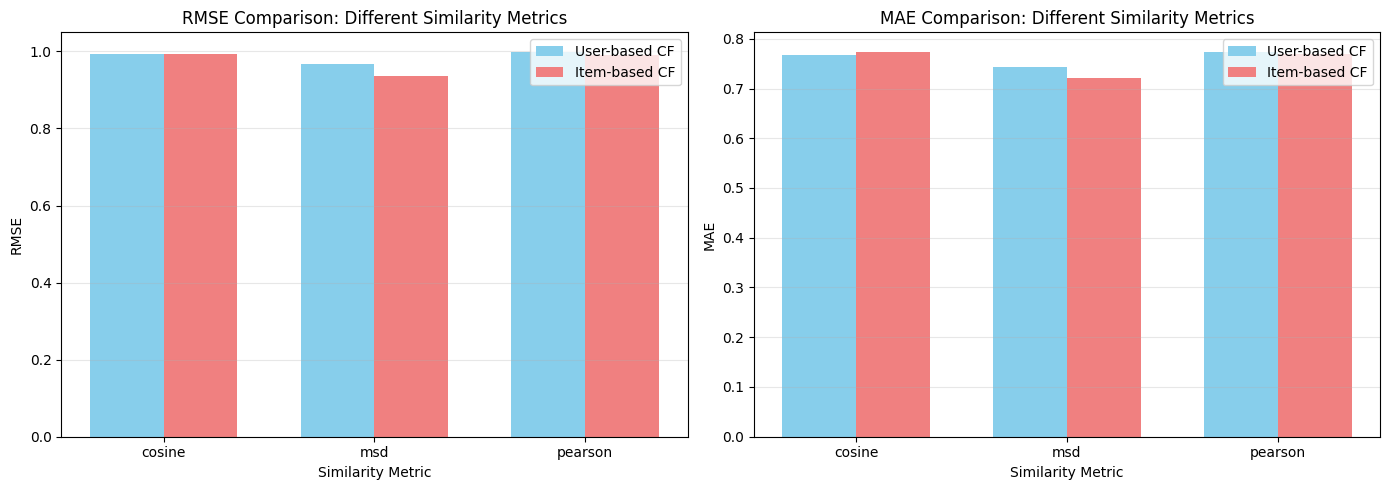

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE comparison
x = range(len(sims))
width = 0.35

axes[0].bar([i - width/2 for i in x], user_rmse, width, label='User-based CF', color='skyblue')
axes[0].bar([i + width/2 for i in x], item_rmse, width, label='Item-based CF', color='lightcoral')
axes[0].set_xlabel('Similarity Metric')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Comparison: Different Similarity Metrics')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sims)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot MAE comparison
axes[1].bar([i - width/2 for i in x], user_mae, width, label='User-based CF', color='skyblue')
axes[1].bar([i + width/2 for i in x], item_mae, width, label='Item-based CF', color='lightcoral')
axes[1].set_xlabel('Similarity Metric')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE Comparison: Different Similarity Metrics')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sims)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [63]:
k_values = [5, 10, 20, 30, 40, 50, 60, 80, 100]

user_cf_k_results = {}

In [64]:
for k in k_values:
    print(f"\nTesting User-based CF with K={k}...")

    sim_options = {
        'name': 'cosine',
        'user_based': True
    }

    algo = KNNBasic(k=k, sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    user_cf_k_results[k] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {user_cf_k_results[k]['rmse']:.4f}")
    print(f"  MAE:  {user_cf_k_results[k]['mae']:.4f}")


Testing User-based CF with K=5...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0437
  MAE:  0.8061

Testing User-based CF with K=10...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0100
  MAE:  0.7787

Testing User-based CF with K=20...
Computing the cosine similarity matrix...
Done computing similarity matri

In [65]:
item_cf_k_results = {}

for k in k_values:
    print(f"\nTesting Item-based CF with K={k}...")

    sim_options = {
        'name': 'cosine',
        'user_based': False
    }

    algo = KNNBasic(k=k, sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    item_cf_k_results[k] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {item_cf_k_results[k]['rmse']:.4f}")
    print(f"  MAE:  {item_cf_k_results[k]['mae']:.4f}")


Testing Item-based CF with K=5...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0963
  MAE:  0.8555

Testing Item-based CF with K=10...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0527
  MAE:  0.8233

Testing Item-based CF with K=20...
Computing the cosine similarity matrix...
Done computing similarity matri

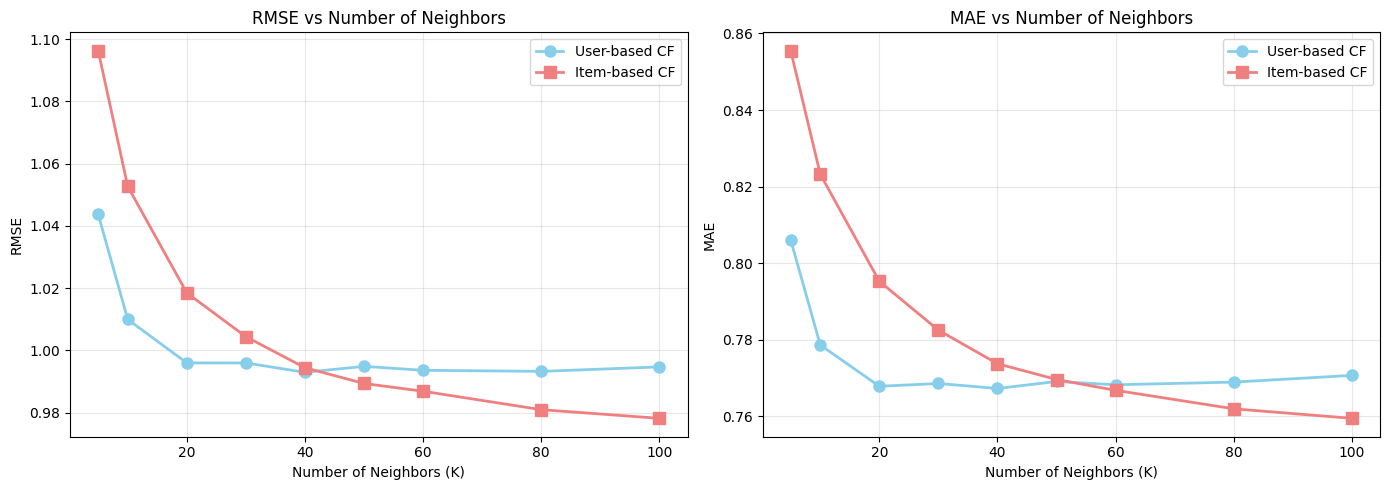

In [66]:
# Prepare data for plotting
k_list = list(k_values)
user_rmse_k = [user_cf_k_results[k]['rmse'] for k in k_list]
user_mae_k = [user_cf_k_results[k]['mae'] for k in k_list]
item_rmse_k = [item_cf_k_results[k]['rmse'] for k in k_list]
item_mae_k = [item_cf_k_results[k]['mae'] for k in k_list]

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE vs K
axes[0].plot(k_list, user_rmse_k, marker='o', label='User-based CF', linewidth=2, markersize=8, color='skyblue')
axes[0].plot(k_list, item_rmse_k, marker='s', label='Item-based CF', linewidth=2, markersize=8, color='lightcoral')
axes[0].set_xlabel('Number of Neighbors (K)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs Number of Neighbors')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot MAE vs K
axes[1].plot(k_list, user_mae_k, marker='o', label='User-based CF', linewidth=2, markersize=8, color='skyblue')
axes[1].plot(k_list, item_mae_k, marker='s', label='Item-based CF', linewidth=2, markersize=8, color='lightcoral')
axes[1].set_xlabel('Number of Neighbors (K)')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE vs Number of Neighbors')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
# Find the best K for User-based CF
best_k_user_rmse = min(user_cf_k_results.items(), key=lambda x: x[1]['rmse'])
best_k_user_mae  = min(user_cf_k_results.items(), key=lambda x: x[1]['mae'])

# Find the best K for Item-based CF
best_k_item_rmse = min(item_cf_k_results.items(), key=lambda x: x[1]['rmse'])
best_k_item_mae  = min(item_cf_k_results.items(), key=lambda x: x[1]['mae'])

print("\nUser-based Collaborative Filtering:")
print(f"  Best K by RMSE: K={best_k_user_rmse[0]} (RMSE={best_k_user_rmse[1]['rmse']:.4f})")
print(f"  Best K by MAE:  K={best_k_user_mae[0]}  (MAE={best_k_user_mae[1]['mae']:.4f})")

print("\nItem-based Collaborative Filtering:")
print(f"  Best K by RMSE: K={best_k_item_rmse[0]} (RMSE={best_k_item_rmse[1]['rmse']:.4f})")
print(f"  Best K by MAE:  K={best_k_item_mae[0]}  (MAE={best_k_item_mae[1]['mae']:.4f})")

if best_k_user_rmse[0] == best_k_item_rmse[0]:
    print(f"\n✓ Both methods have the same best K: {best_k_user_rmse[0]}")
else:
    print("\n✗ Different best K values:")
    print(f"  User-based CF best K:  {best_k_user_rmse[0]}")
    print(f"  Item-based CF best K:  {best_k_item_rmse[0]}")



User-based Collaborative Filtering:
  Best K by RMSE: K=40 (RMSE=0.9930)
  Best K by MAE:  K=40  (MAE=0.7673)

Item-based Collaborative Filtering:
  Best K by RMSE: K=100 (RMSE=0.9782)
  Best K by MAE:  K=100  (MAE=0.7595)

✗ Different best K values:
  User-based CF best K:  40
  Item-based CF best K:  100


In [68]:
print("\n1. BASIC ALGORITHM COMPARISON (Part c & d):")
print("-" * 70)
print(f"{'Algorithm':<25} {'RMSE':<15} {'MAE':<15}")
print("-" * 70)
print(f"{'User-based CF':<25} {avg_rmse_user:<15.4f} {avg_mae_user:<15.4f}")
print(f"{'Item-based CF':<25} {avg_rmse_item:<15.4f} {avg_mae_item:<15.4f}")
print(f"{'PMF (SVD)':<25} {avg_rmse_pmf:<15.4f} {avg_mae_pmf:<15.4f}")
print("-" * 70)
print(f"Best Model: {best_rmse_model[0]}")


1. BASIC ALGORITHM COMPARISON (Part c & d):
----------------------------------------------------------------------
Algorithm                 RMSE            MAE            
----------------------------------------------------------------------
User-based CF             0.9671          0.7438         
Item-based CF             0.9355          0.7213         
PMF (SVD)                 0.8947          0.6888         
----------------------------------------------------------------------
Best Model: PMF


In [69]:
print("\n2. SIMILARITY METRIC COMPARISON (Part e):")
print("-" * 70)
print("User-based CF:")
for sim in similarities:
    print(f"  {sim:<10} - RMSE: {user_cf_results[sim]['rmse']:.4f}, MAE: {user_cf_results[sim]['mae']:.4f}")

print("\nItem-based CF:")
for sim in similarities:
    print(f"  {sim:<10} - RMSE: {item_cf_results[sim]['rmse']:.4f}, MAE: {item_cf_results[sim]['mae']:.4f}")


2. SIMILARITY METRIC COMPARISON (Part e):
----------------------------------------------------------------------
User-based CF:
  cosine     - RMSE: 0.9937, MAE: 0.7679
  msd        - RMSE: 0.9677, MAE: 0.7438
  pearson    - RMSE: 0.9994, MAE: 0.7736

Item-based CF:
  cosine     - RMSE: 0.9944, MAE: 0.7742
  msd        - RMSE: 0.9349, MAE: 0.7209
  pearson    - RMSE: 0.9900, MAE: 0.7687


In [70]:
print("\n3. OPTIMAL K VALUES (Part f & g):")
print("-" * 70)
print(f"User-based CF - Best K: {best_k_user_rmse[0]} (RMSE: {best_k_user_rmse[1]['rmse']:.4f})")
print(f"Item-based CF - Best K: {best_k_item_rmse[0]} (RMSE: {best_k_item_rmse[1]['rmse']:.4f})")
print(f"\nAre optimal K values the same? {'Yes' if best_k_user_rmse[0] == best_k_item_rmse[0] else 'No'}")


3. OPTIMAL K VALUES (Part f & g):
----------------------------------------------------------------------
User-based CF - Best K: 40 (RMSE: 0.9930)
Item-based CF - Best K: 100 (RMSE: 0.9782)

Are optimal K values the same? No
